<a href="https://colab.research.google.com/github/Divine193/TS-ACADEMY-PROJECT/blob/main/Notebook/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### CUSTOMER CHURN

In [6]:
# import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Load the dataset
customer_churn = pd.read_csv("/content/drive/MyDrive/Telco-Customer-Churn.csv")

In [9]:
# The first ten items
customer_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# the columns ot the table
customer_churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
# the data types of the columns
print(customer_churn.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [12]:
# the summary of the data
customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
# shape of the dataset
customer_churn.shape

(7043, 21)

In [14]:
# Summary Statistics
customer_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## **Data** **Preparation** & **Cleaning**

In [15]:
# the data types of the columns
print(customer_churn.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [16]:
# Convert the naming conventions to snake case for easy readability
import re
def to_snake_case(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

customer_churn.columns = [to_snake_case(col) for col in customer_churn.columns]
display(customer_churn.head())

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# Convert the total charges to numeric data type
customer_churn['total_charges'] = pd.to_numeric(customer_churn['total_charges'], errors='coerce')
print(customer_churn['total_charges'].dtype)
print(f"Number of missing values in 'total_charges' after conversion: {customer_churn['total_charges'].isnull().sum()}")

float64
Number of missing values in 'total_charges' after conversion: 11


In [18]:
# Drop missing rows in the total charges column
customer_churn.dropna(inplace=True)
print(f"Shape of the DataFrame after dropping rows with missing 'total_charges': {customer_churn.shape}")

Shape of the DataFrame after dropping rows with missing 'total_charges': (7032, 21)


In [19]:
# check for missing values after dropping NaNs
customer_churn.isna().sum()

,0
customer_id,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0


In [20]:
# check for duplicates
customer_churn.duplicated().sum()

np.int64(0)

In [21]:
# Quick check of the dataset
customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   gender             7032 non-null   object 
 2   senior_citizen     7032 non-null   int64  
 3   partner            7032 non-null   object 
 4   dependents         7032 non-null   object 
 5   tenure             7032 non-null   int64  
 6   phone_service      7032 non-null   object 
 7   multiple_lines     7032 non-null   object 
 8   internet_service   7032 non-null   object 
 9   online_security    7032 non-null   object 
 10  online_backup      7032 non-null   object 
 11  device_protection  7032 non-null   object 
 12  tech_support       7032 non-null   object 
 13  streaming_tv       7032 non-null   object 
 14  streaming_movies   7032 non-null   object 
 15  contract           7032 non-null   object 
 16  paperless_billing  7032 non-n

## **EDA**

In [22]:
# Put the columns into a list
full_cols = customer_churn.columns
full_cols.to_list()

['customer_id',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn']

In [23]:
# Seperate Numerical Columns from Categorical Columns
num_cols = full_cols[customer_churn.dtypes != 'object']
cat_cols = full_cols[customer_churn.dtypes == 'object']
print(num_cols)
print(cat_cols)

Index(['senior_citizen', 'tenure', 'monthly_charges', 'total_charges'], dtype='object')
Index(['customer_id', 'gender', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'churn'],
      dtype='object')


### **UNIVARIATE** **ANALYSIS** **FOR NUMERIC COLUMNS**

In [24]:
# Summary Statistics
customer_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
senior_citizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
monthly_charges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
total_charges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


Text(0.5, 1.0, 'Distribution of SeniorCitizen')

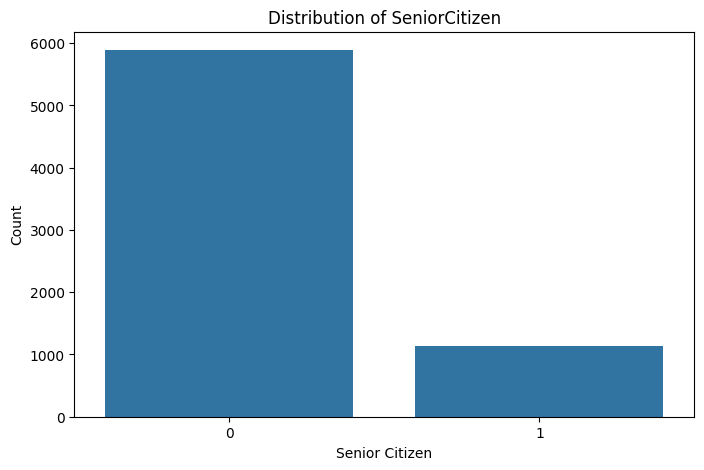

In [25]:
# Distribution of Senior Citizens
plt.figure(figsize=(8,5))
sns.countplot(x='senior_citizen',data=customer_churn)
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.title('Distribution of SeniorCitizen')

Text(0.5, 1.0, 'Distribution of Tenure')

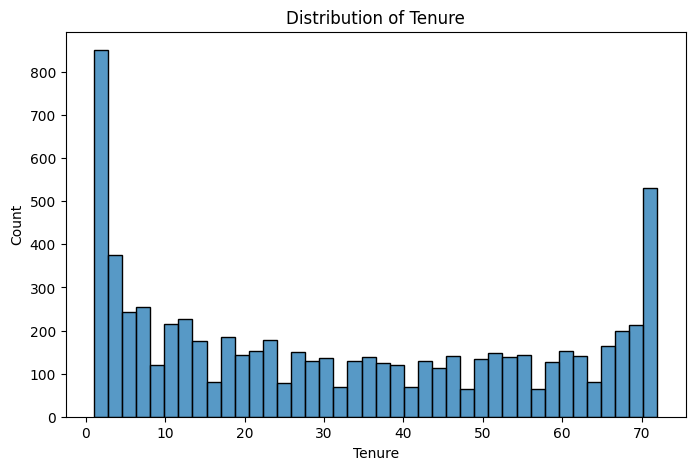

In [26]:
# Distribution of Tenure
plt.figure(figsize=(8,5))
sns.histplot(customer_churn, x='tenure', bins=40)
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Distribution of Tenure')

Text(0.5, 1.0, 'Distribution of Monthly Charges')

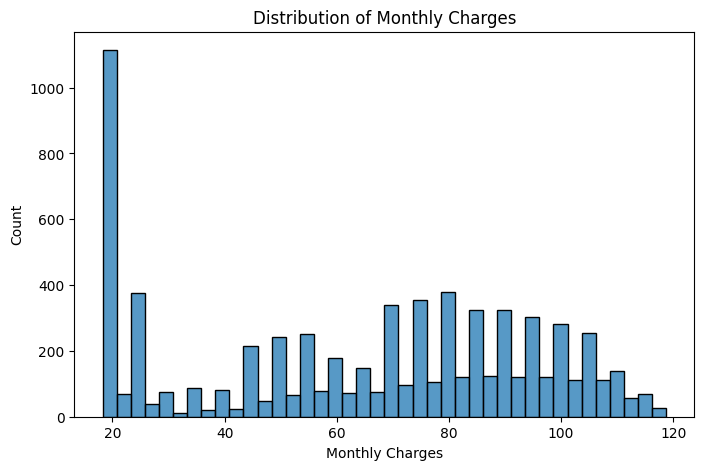

In [27]:
# Distribution of Monthly Charges
plt.figure(figsize=(8,5))
sns.histplot(customer_churn, x='monthly_charges', bins=40)
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.title('Distribution of Monthly Charges')

Text(0.5, 1.0, 'Distribution of Total Charges')

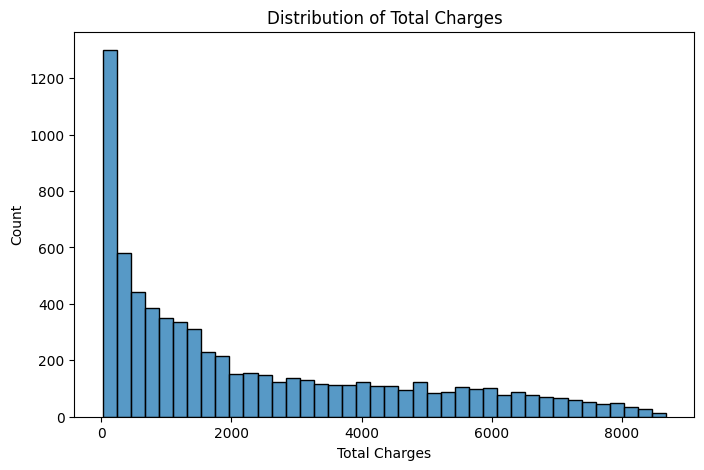

In [28]:
# Distribution of Total Charges
plt.figure(figsize=(8,5))
sns.histplot(customer_churn, x='total_charges', bins=40)
plt.xlabel('Total Charges')
plt.ylabel('Count')
plt.title('Distribution of Total Charges')

### **UNIVARIATE ANALYSIS FOR CATEGORICAL VARIABLES**

In [29]:
# Drop customer id column as it isn't needed
customer_churn.drop(['customer_id'],axis=1, inplace = True)

In [30]:
# Examine the target variable & checking for imbalance
print("Value counts for 'churn' column:")
print(customer_churn['churn'].value_counts())
print("\nPercentage of each category in 'churn' column:")
print(customer_churn['churn'].value_counts(normalize=True) * 100)

Value counts for 'churn' column:
churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage of each category in 'churn' column:
churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Text(0, 0.5, 'Number of Customers')

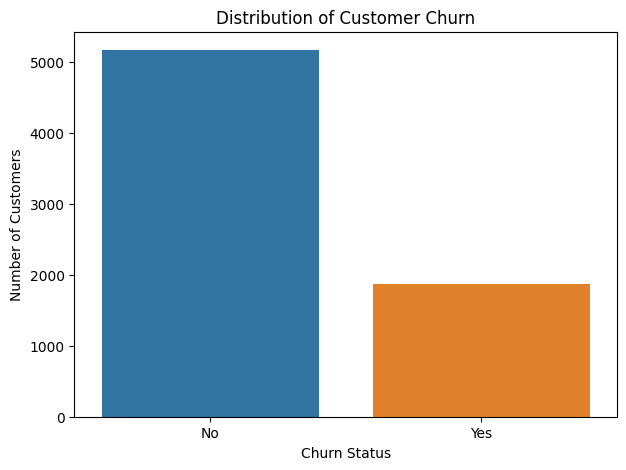

In [31]:
# Distribution of Customer Churn
plt.figure(figsize=(7, 5))
sns.countplot(x='churn', data=customer_churn, hue='churn')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

In [32]:
# The categorical features
categorical_features = customer_churn.select_dtypes(include='object').columns.tolist()
print(f"All categorical columns: {categorical_features}")

All categorical columns: ['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'churn']


In [33]:
# Split the categorical columns into binary and multi level for better examination
binary_categorical_cols = []
multi_level_categorical_cols = []

for col in categorical_features:
    if customer_churn[col].nunique() == 2:
        binary_categorical_cols.append(col)
    else:
        multi_level_categorical_cols.append(col)

print(f"Binary Categorical Columns: {binary_categorical_cols}")
print(f"Multi-level Categorical Columns: {multi_level_categorical_cols}")

Binary Categorical Columns: ['gender', 'partner', 'dependents', 'phone_service', 'paperless_billing', 'churn']
Multi-level Categorical Columns: ['multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'payment_method']


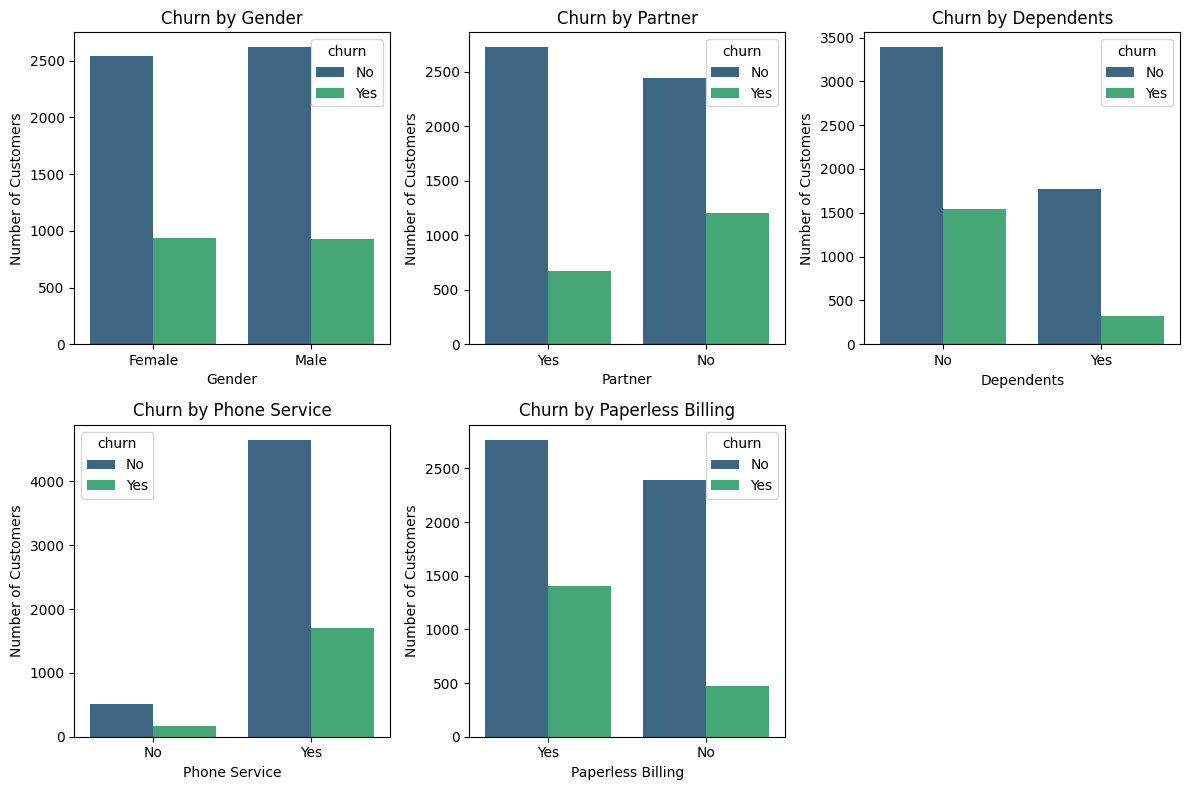

In [34]:
# Distribution of Binary Categorical Features
# Exclude 'churn' from binary_categorical_cols for plotting against churn
binary_features_for_plotting = [col for col in binary_categorical_cols if col != 'churn']

plt.figure(figsize=(12, 8))
for i, col in enumerate(binary_features_for_plotting):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on the number of features
    sns.countplot(data=customer_churn, x=col, hue='churn', palette='viridis')
    plt.title(f'Churn by {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Number of Customers')
    plt.tight_layout()

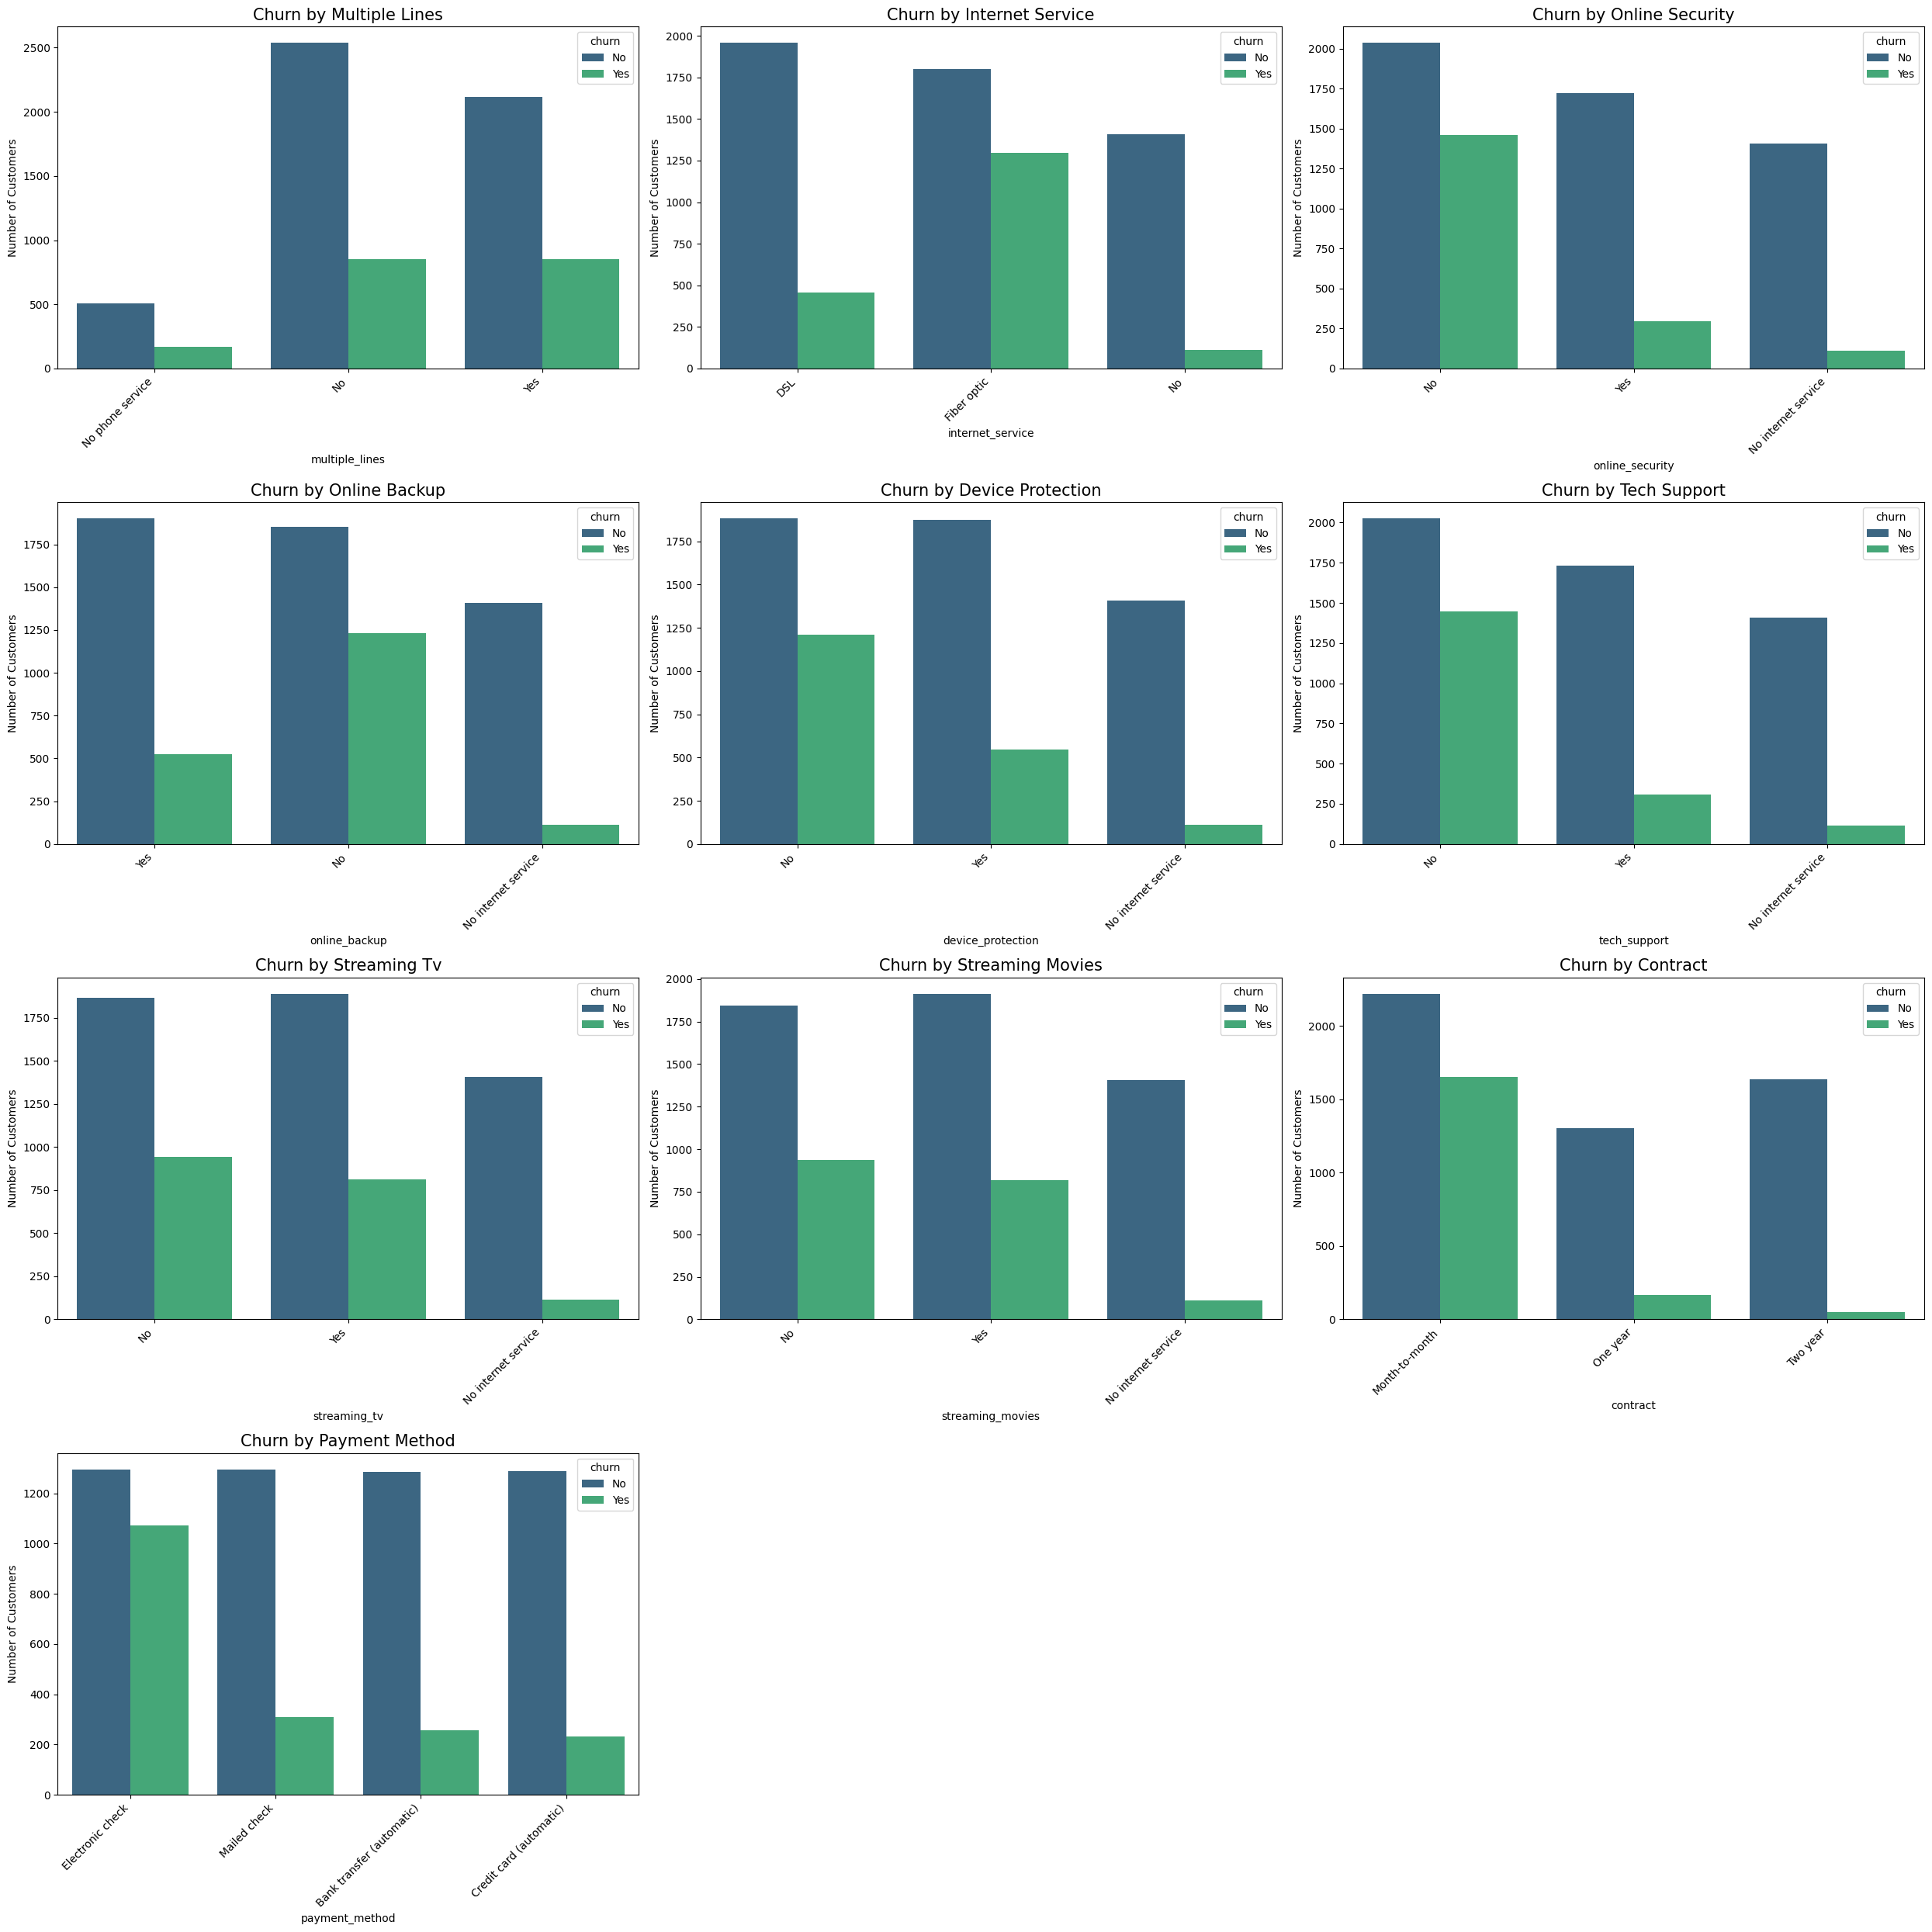

In [35]:
# Distribution of the Multi-level Categorical Features
plt.figure(figsize=(25, 25))
for i, col in enumerate(multi_level_categorical_cols):
    plt.subplot(4, 3, i + 1)  # Adjust subplot grid based on the number of features
    sns.countplot(data=customer_churn, x=col, hue='churn', palette='viridis')
    plt.title(f'Churn by {col.replace("_", " ").title()}', fontsize=15)
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout()

## **Explore Value Counts for the Categorical Variables**

In [36]:
# Binary Categorical Columns
print("Value Counts and Proportions for Binary Categorical Columns (excluding 'churn'):\n")
for col in binary_features_for_plotting:
    print(f"Column: {col.replace('_', ' ').title()}")
    print(customer_churn[col].value_counts())
    print(customer_churn[col].value_counts(normalize=True) * 100)
    print("\n" + "-"*50 + "\n")

Value Counts and Proportions for Binary Categorical Columns (excluding 'churn'):

Column: Gender
gender
Male      3549
Female    3483
Name: count, dtype: int64
gender
Male      50.469283
Female    49.530717
Name: proportion, dtype: float64

--------------------------------------------------

Column: Partner
partner
No     3639
Yes    3393
Name: count, dtype: int64
partner
No     51.749147
Yes    48.250853
Name: proportion, dtype: float64

--------------------------------------------------

Column: Dependents
dependents
No     4933
Yes    2099
Name: count, dtype: int64
dependents
No     70.150739
Yes    29.849261
Name: proportion, dtype: float64

--------------------------------------------------

Column: Phone Service
phone_service
Yes    6352
No      680
Name: count, dtype: int64
phone_service
Yes    90.32992
No      9.67008
Name: proportion, dtype: float64

--------------------------------------------------

Column: Paperless Billing
paperless_billing
Yes    4168
No     2864
Name: co

In [37]:
# Value Counts for Multi Level Categorical Columns
print("Value Counts and Proportions for Multi-level Categorical Columns:\n")
for col in multi_level_categorical_cols:
    print(f"Column: {col.replace('_', ' ').title()}")
    print(customer_churn[col].value_counts())
    print(customer_churn[col].value_counts(normalize=True) * 100)
    print("\n" + "-"*50 + "\n")

Value Counts and Proportions for Multi-level Categorical Columns:

Column: Multiple Lines
multiple_lines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
multiple_lines
No                  48.137088
Yes                 42.192833
No phone service     9.670080
Name: proportion, dtype: float64

--------------------------------------------------

Column: Internet Service
internet_service
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
internet_service
Fiber optic    44.027304
DSL            34.357224
No             21.615472
Name: proportion, dtype: float64

--------------------------------------------------

Column: Online Security
online_security
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64
online_security
No                     49.729807
Yes                    28.654721
No internet service    21.615472
Name: proportion, dtype: float64

## Summary:

### Q&A
1.  **What is the distribution of the 'churn' variable?**
    The 'churn' variable is imbalanced, with 73.42% of customers not churning ('No') and 26.58% churning ('Yes').

2.  **Which features are identified as binary categorical, and which are multi-level categorical?**
    *   **Binary Categorical Columns** (excluding 'churn'): `gender`, `partner`, `dependents`, `phone_service`, `paperless_billing`.
    *   **Multi-level Categorical Columns**: `multiple_lines`, `internet_service`, `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`, `contract`, `payment_method`.

### Data Analysis Key Findings
*   The baseline churn rate for customers is approximately 26.58%, indicating a moderate level of customer attrition. The target variable is imbalanced, with 'No' churn significantly outweighing 'Yes' churn.
*   **Binary Categorical Features:**
    *   `gender` is well-balanced between Male (\~50.5%) and Female (\~49.5%).
    *   `partner` shows a slight imbalance, with more customers without a partner (\~51.7%) than with one (\~48.3%).
    *   `dependents` is notably imbalanced, with a large majority of customers having no dependents (\~70.1%).
    *   `phone_service` is highly imbalanced, with most customers having phone service (\~90.3%).
    *   `paperless_billing` is relatively balanced, with 'Yes' slightly more prevalent (\~59.3%) than 'No' (\~40.7%).
*   **Multi-level Categorical Features:**
    *   `multiple_lines` has 'No' (\~48.1%) and 'Yes' (\~42.2%) as primary categories, with 'No phone service' (\~9.7%) mirroring the proportion of customers without phone service.
    *   `internet_service` is dominated by 'Fiber optic' (\~44.0%), followed by 'DSL' (\~34.4%), and a substantial portion with 'No' internet service (\~21.6%).
    *   For services like `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, and `streaming_movies`, approximately 21.6% of customers consistently have 'No internet service', which means these services are not applicable to them. Among those with internet service, the 'No' option for these services is generally more frequent than 'Yes'.
    *   `contract` types are heavily skewed towards 'Month-to-month' (\~55.1%), suggesting a high proportion of customers on short-term commitments, which might correlate with higher churn.
    *   `payment_method` is relatively evenly distributed, with 'Electronic check' being the most common (\~33.6%).

### Insights or Next Steps
*   The imbalance in the 'churn' target variable suggests that resampling techniques (e.g., oversampling, undersampling) or using appropriate evaluation metrics (e.g., F1-score, ROC AUC) will be crucial during model training to avoid bias towards the majority class.
*   The high proportion of 'Month-to-month' contracts and the significant segment of customers with 'Fiber optic' internet service (known for speed but sometimes less reliability) are important segments to analyze further for churn risk. The interaction between these features and churn should be explored in more detail.


## **Bivariate Analysis**

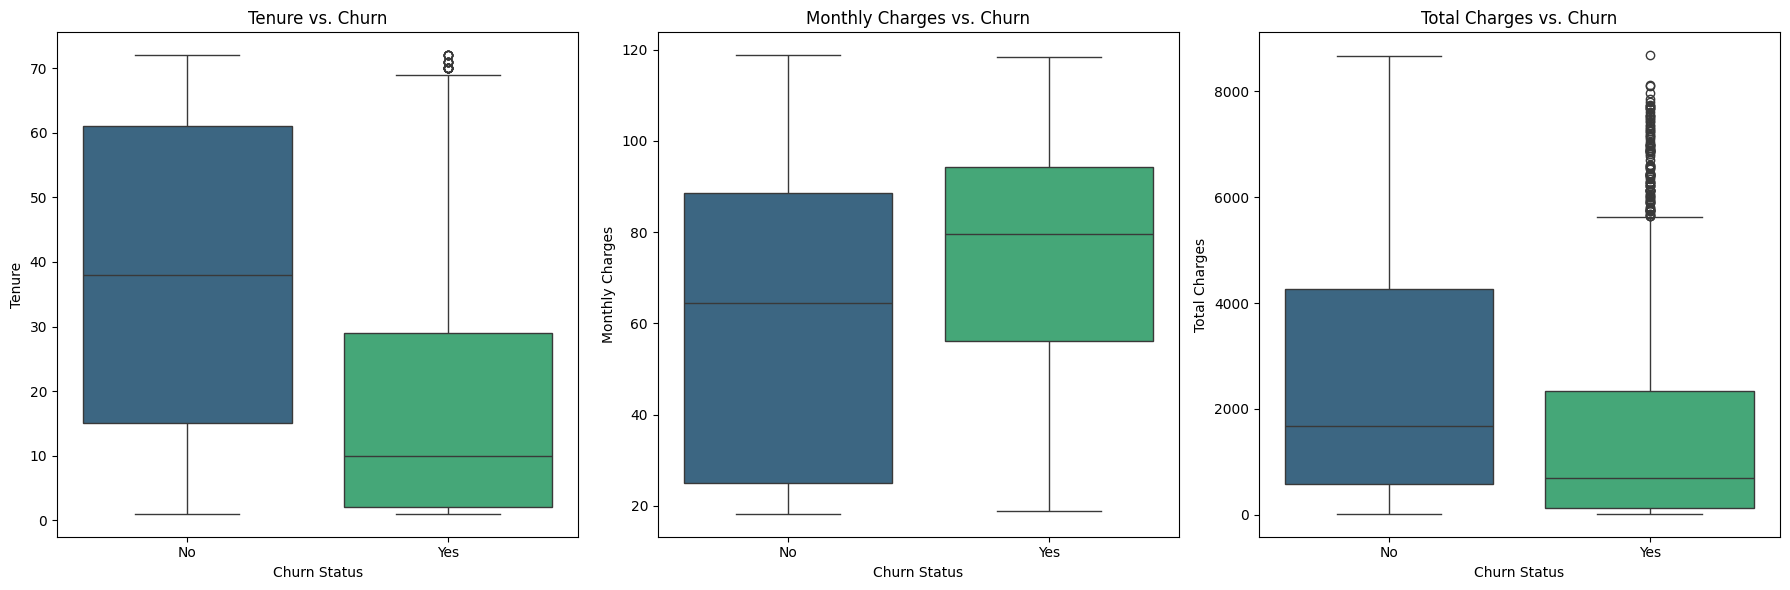

In [38]:
# Bivariate Analysis of the Numerical features with the target variable
numerical_features = ['tenure', 'monthly_charges', 'total_charges']

plt.figure(figsize=(18, 6))

for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=customer_churn, x='churn', y=col, hue='churn', palette='viridis')
    plt.title(f'{col.replace("_", " ").title()} vs. Churn')
    plt.xlabel('Churn Status')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()


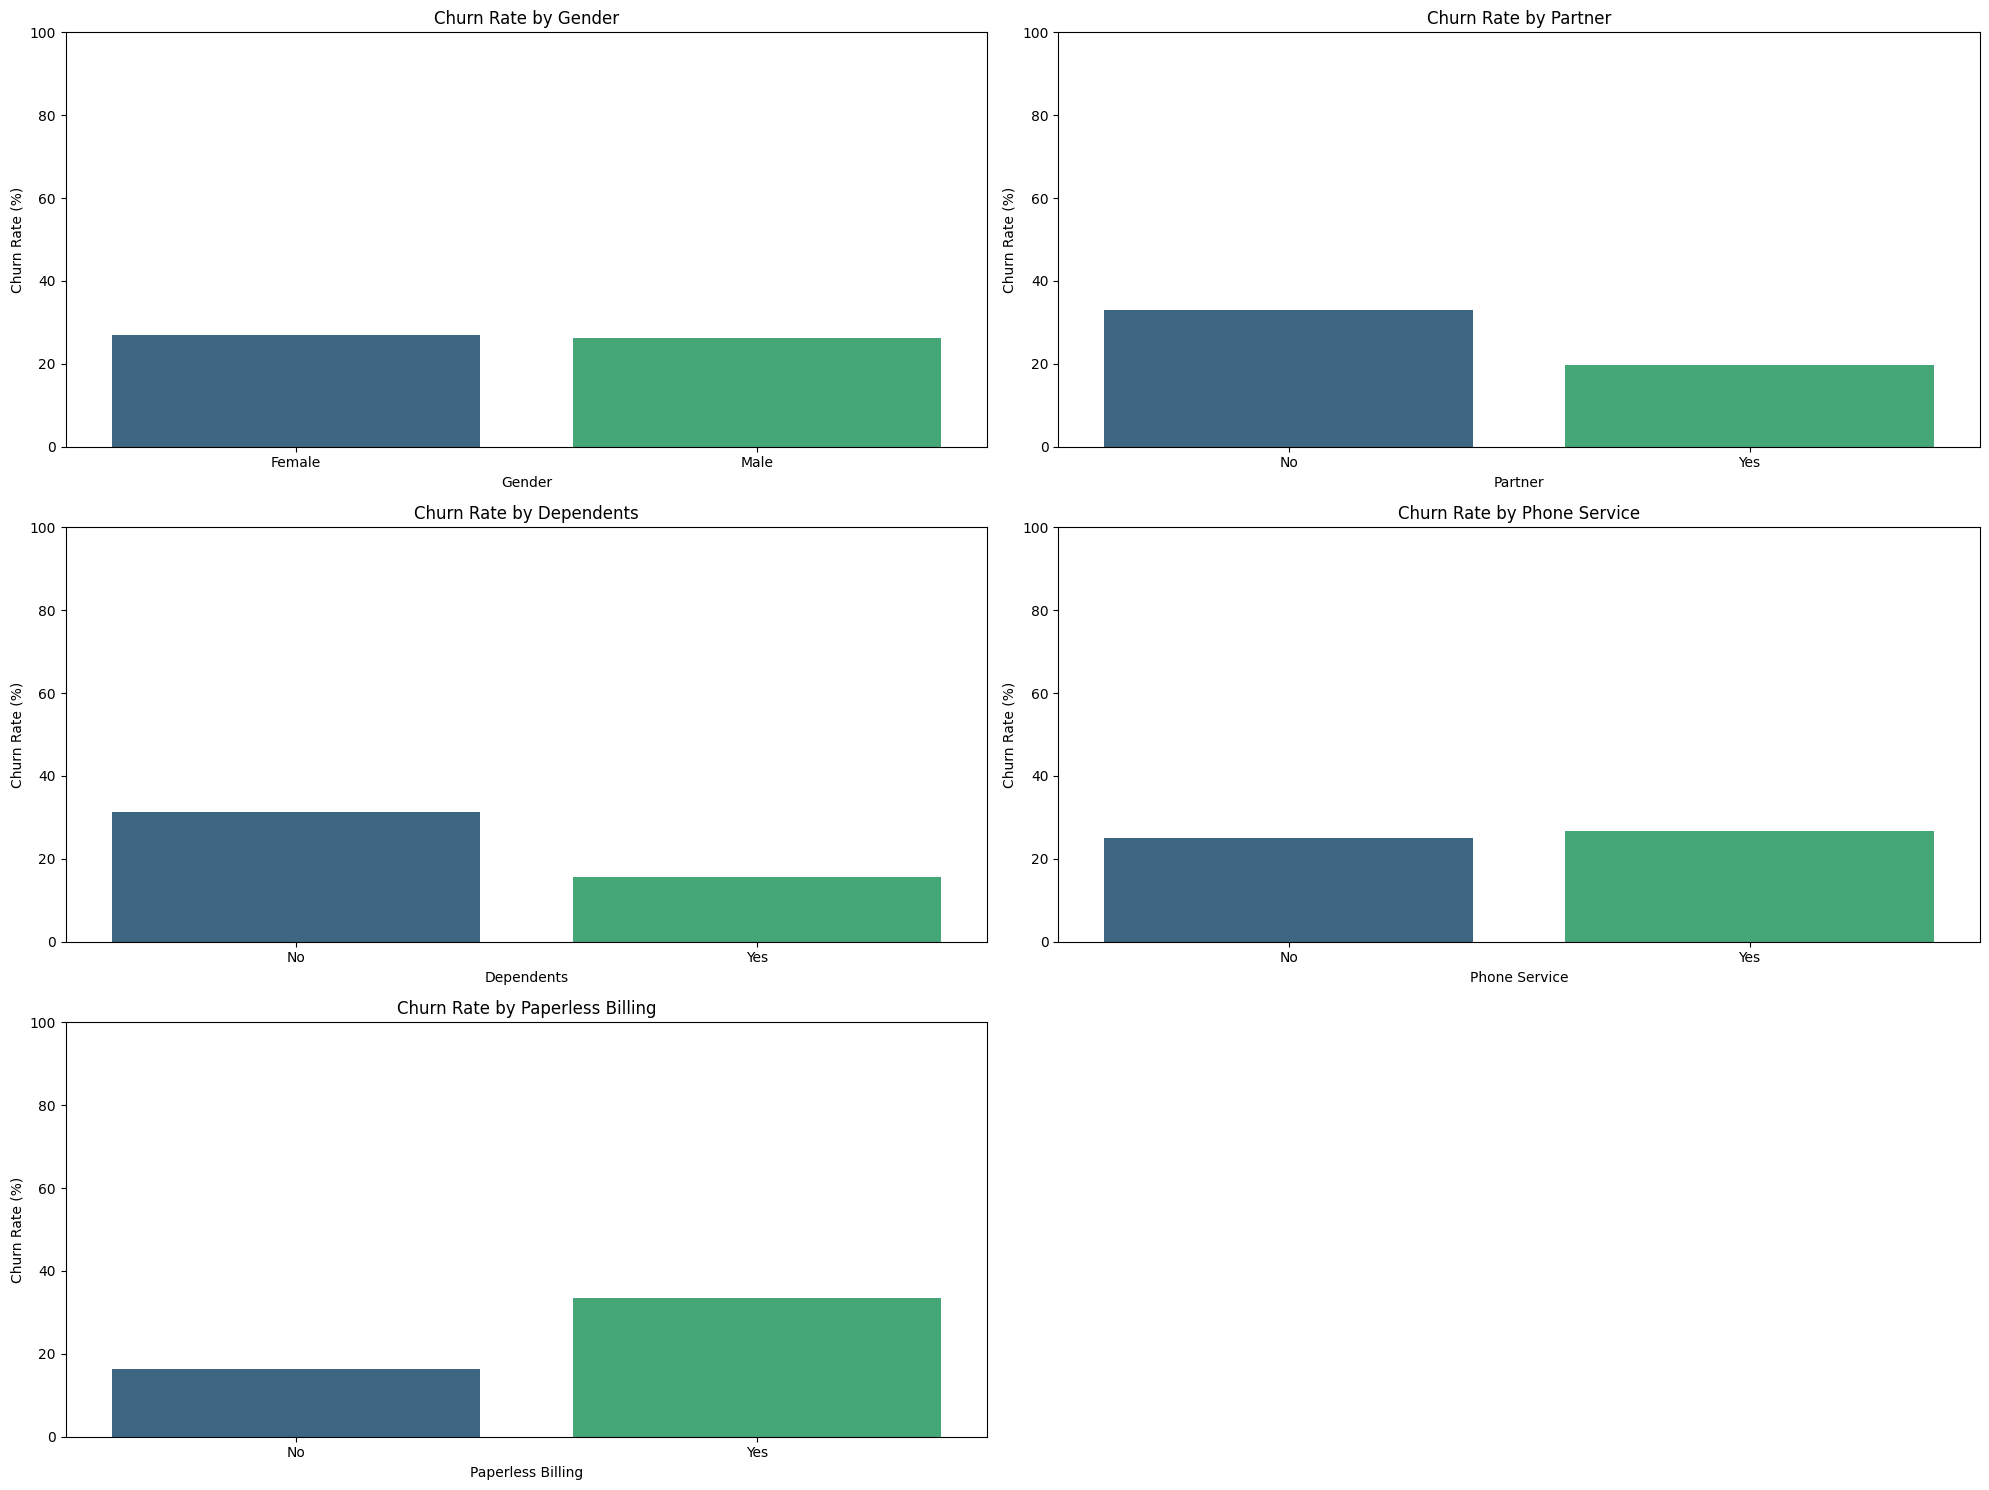

In [39]:
# Bivariate Analysis of the Binary Features
plt.figure(figsize=(20, 15))

for i, col in enumerate(binary_features_for_plotting):
    # Calculate churn rate for each category
    churn_rate = customer_churn.groupby(col)['churn'].value_counts(normalize=True).unstack().get('Yes', pd.Series(0, index=customer_churn[col].unique()))

    # Convert to percentage for better readability
    churn_rate_percent = churn_rate * 100

    plt.subplot(3, 2, i + 1) # Adjust subplot grid based on the number of features
    sns.barplot(x=churn_rate_percent.index, y=churn_rate_percent.values, hue=churn_rate_percent.index, palette='viridis', legend=False)
    plt.title(f'Churn Rate by {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Churn Rate (%)')
    plt.ylim(0, 100) # Ensure y-axis is from 0 to 100 for percentage

plt.tight_layout()

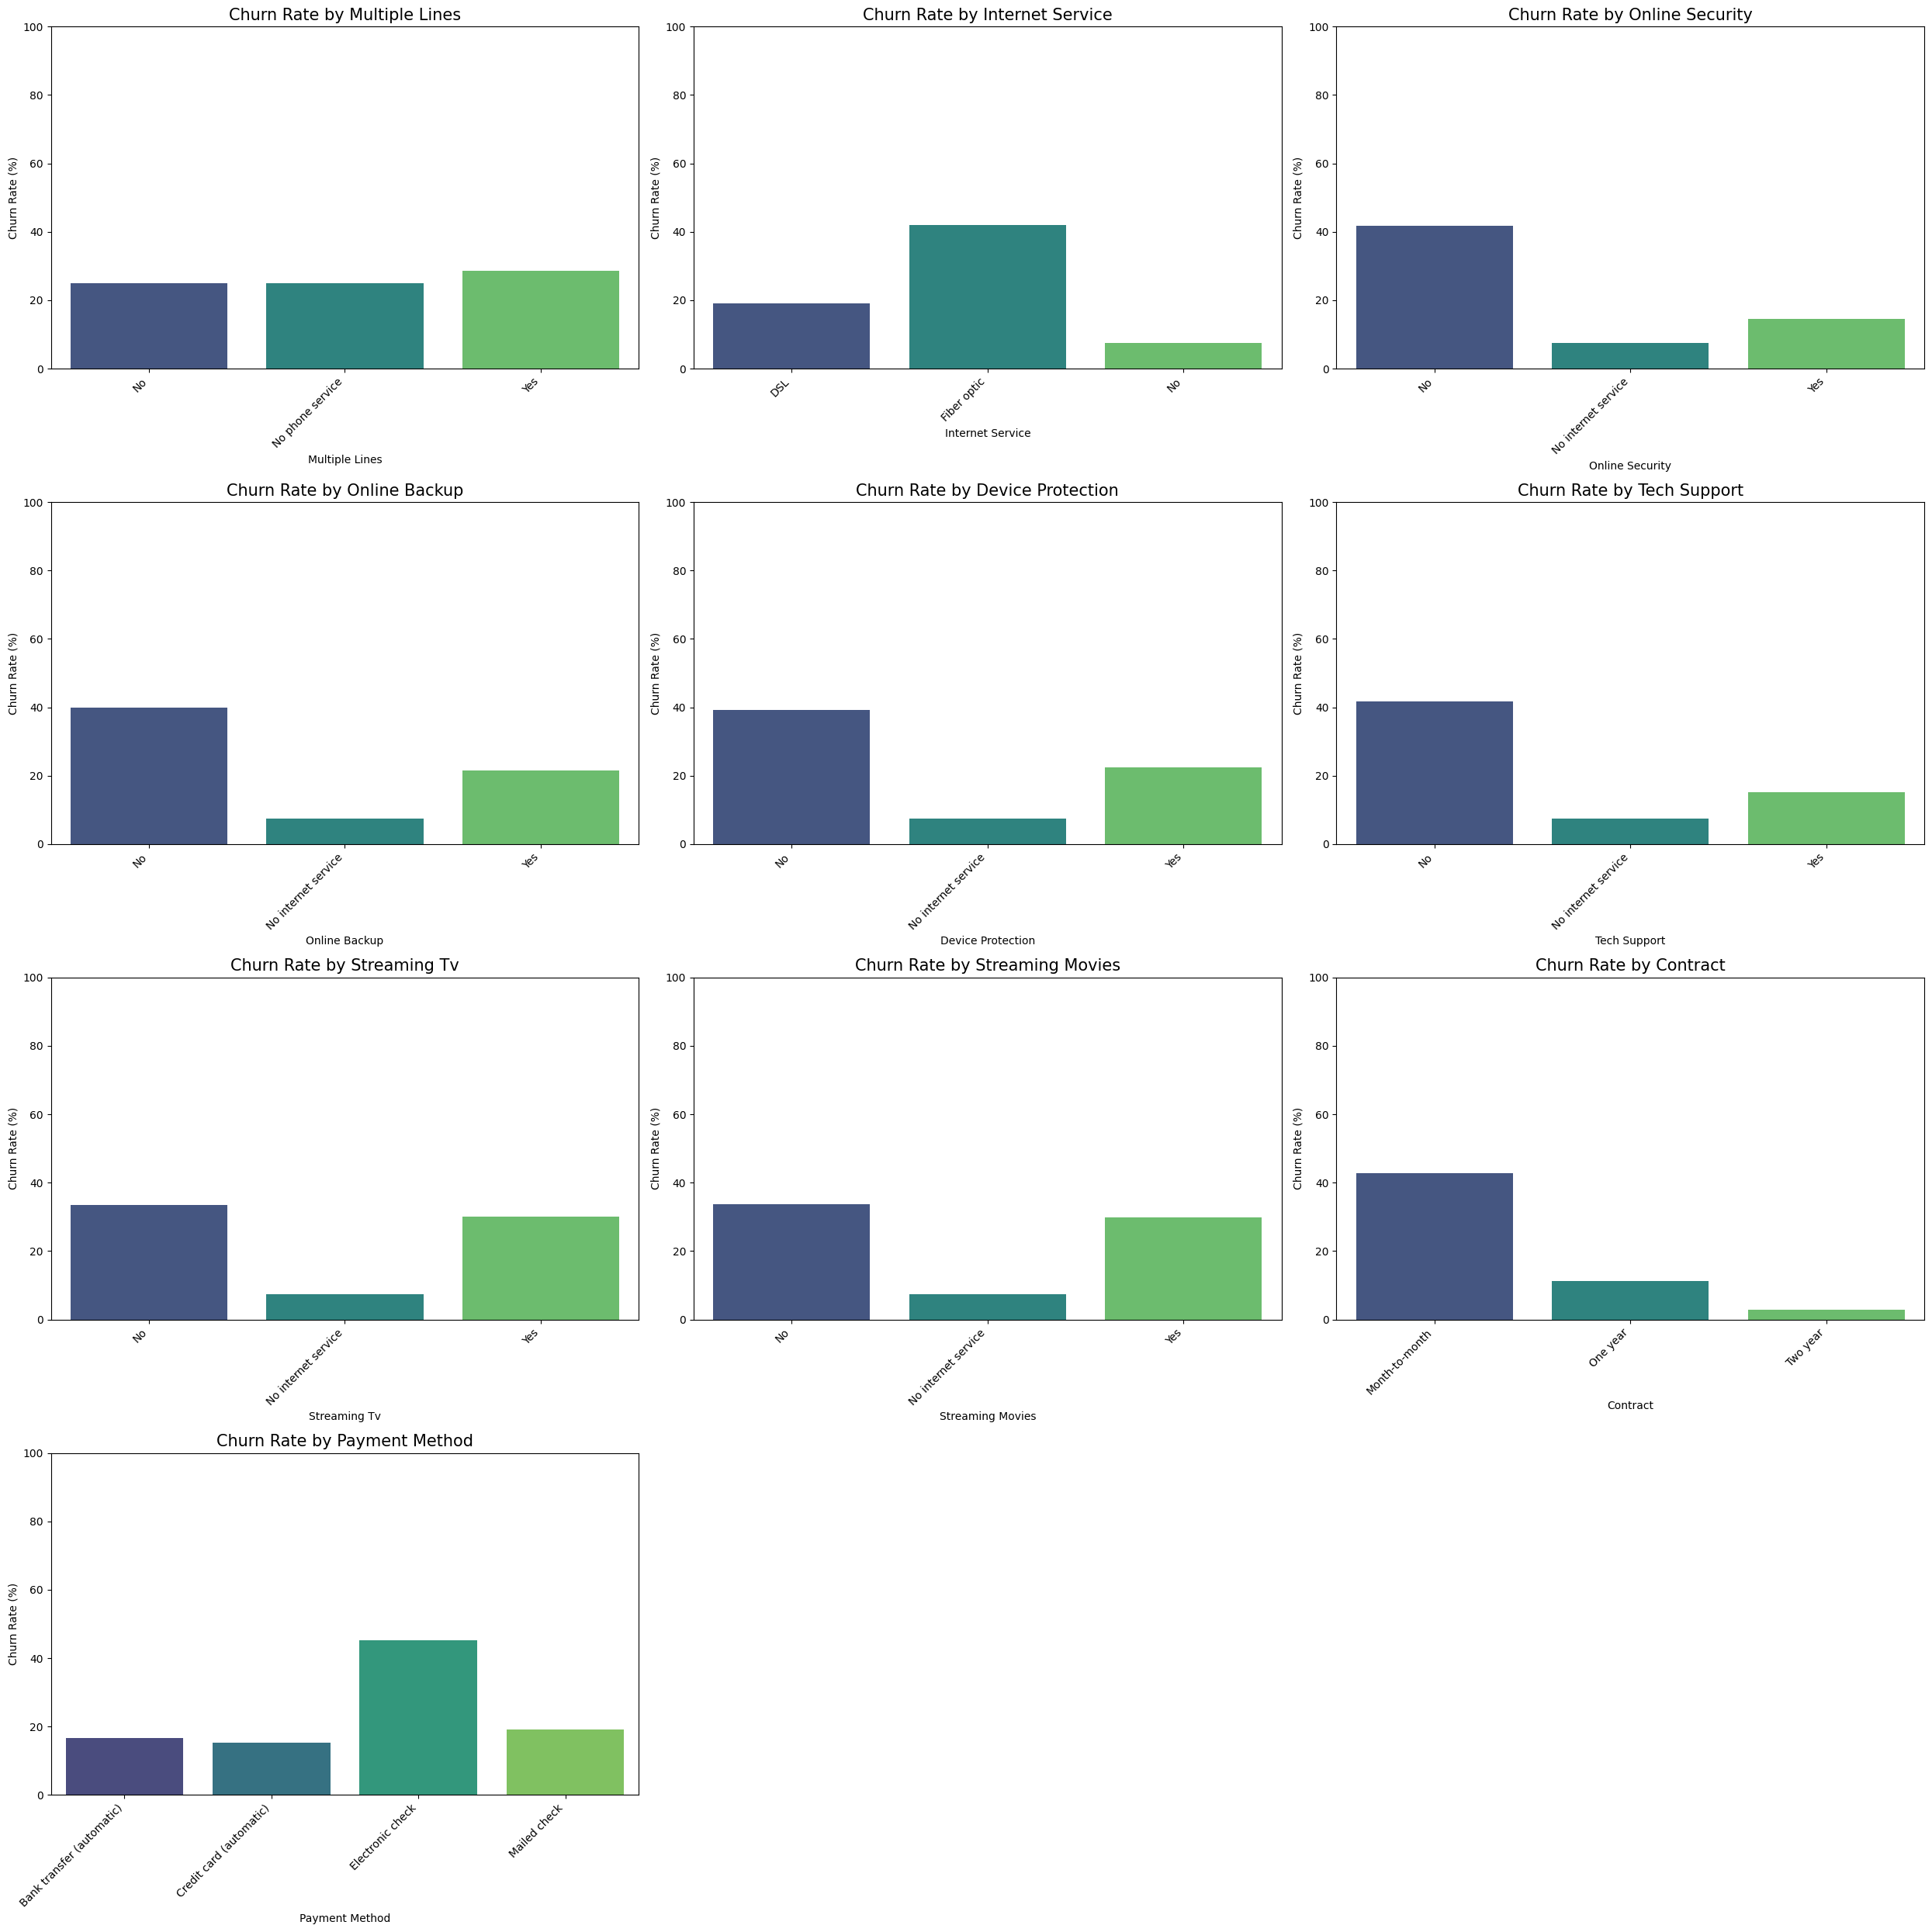

In [40]:
# Bivariate Analysis for Multi Level Characteristics
plt.figure(figsize=(25, 25))

for i, col in enumerate(multi_level_categorical_cols):
    # Calculate churn rate for each category
    churn_rate = customer_churn.groupby(col)['churn'].value_counts(normalize=True).unstack().get('Yes', pd.Series(0, index=customer_churn[col].unique()))

    # Convert to percentage for better readability
    churn_rate_percent = churn_rate * 100

    plt.subplot(4, 3, i + 1)  # Adjust subplot grid based on the number of features
    sns.barplot(x=churn_rate_percent.index, y=churn_rate_percent.values, hue=churn_rate_percent.index, palette='viridis', legend=False)
    plt.title(f'Churn Rate by {col.replace("_", " ").title()}', fontsize=15)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Churn Rate (%)')
    plt.ylim(0, 100)  # Ensure y-axis is from 0 to 100 for percentage
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout()

## Bivariate Analysis Insights

### Numerical Features vs. Churn:
*   **Tenure**: Customers with lower tenure (short-term customers) show a significantly higher churn rate compared to those with longer tenure. The median tenure for churning customers is much lower than for non-churning customers, indicating that new customers are more likely to churn.
*   **Monthly Charges**: Customers with higher monthly charges tend to churn more frequently. The box plot for monthly charges shows that churning customers generally have higher monthly charges than non-churning customers.
*   **Total Charges**: Churning customers tend to have lower total charges compared to non-churning customers. This is consistent with the tenure observation, as customers with shorter tenures (and thus higher churn) would naturally accumulate lower total charges.

### Categorical Features vs. Churn:

#### Binary Categorical Features:
*   **Gender**: Churn rates are very similar for both male and female customers, suggesting gender is not a significant predictor of churn.
*   **Partner**: Customers without a partner have a higher churn rate than those with a partner.
*   **Dependents**: Customers without dependents show a higher churn rate compared to those with dependents.
*   **Phone Service**: There is a slightly higher churn rate among customers who do not have phone service, but the difference is not very large.
*   **Paperless Billing**: Customers who use paperless billing have a noticeably higher churn rate than those who do not.

#### Multi-level Categorical Features:
*   **Multiple Lines**: Customers with multiple lines have a slightly higher churn rate than those with no multiple lines. Customers with 'No phone service' (who cannot have multiple lines) have a churn rate similar to the overall average.
*   **Internet Service**: Customers with 'Fiber optic' internet service have a significantly higher churn rate compared to those with 'DSL' or no internet service. This is a strong indicator of churn.
*   **Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies**: For all these services, customers who do **not** subscribe to them (indicated by 'No') generally have higher churn rates than those who do ('Yes'). Customers with 'No internet service' (for whom these services are not applicable) have lower churn rates, similar to the overall non-churning population. Tech Support and Online Security, in particular, show a strong negative correlation with churn (i.e., customers with these services churn less).
*   **Contract**: 'Month-to-month' contract customers have a dramatically higher churn rate than 'One year' or 'Two year' contract customers. This is one of the most significant predictors of churn.
*   **Payment Method**: 'Electronic check' is associated with the highest churn rate among all payment methods. Customers using 'Bank transfer (automatic)' and 'Credit card (automatic)' have much lower churn rates.

### Key Takeaways:
*   **High Churn Risk Factors**: Short tenure, high monthly charges, Fiber optic internet service, month-to-month contracts, electronic check payment method, and not having online security or tech support are strongly associated with higher churn rates.
*   **Low Churn Risk Factors**: Long tenure, lower monthly charges, DSL or no internet service, one-year or two-year contracts, automatic payment methods (bank transfer, credit card), and having online security or tech support are associated with lower churn rates.
*   **Actionable Insights**: Strategies to reduce churn could focus on incentivizing longer-term contracts, promoting automatic payment methods, improving service quality for fiber optic users, and encouraging the adoption of add-on services like online security and tech support.

## Summary:

### Data Analysis Key Findings

*   **Tenure**: Customers with lower tenure show a significantly higher churn rate, indicating that new customers are more likely to churn.
*   **Monthly Charges**: Customers with higher monthly charges tend to churn more frequently.
*   **Total Charges**: Churning customers tend to have lower total charges, consistent with their shorter tenure.
*   **Gender**: Churn rates are very similar for both male and female customers, suggesting gender is not a significant predictor.
*   **Partner & Dependents**: Customers without a partner or without dependents show higher churn rates.
*   **Paperless Billing**: Customers using paperless billing have a noticeably higher churn rate.
*   **Internet Service**: Customers with 'Fiber optic' internet service have a significantly higher churn rate compared to those with 'DSL' or no internet service.
*   **Service Subscriptions (Online Security, Tech Support)**: Customers who do not subscribe to services like 'Online Security' or 'Tech Support' generally have higher churn rates.
*   **Contract Type**: 'Month-to-month' contract customers have a dramatically higher churn rate than 'One year' or 'Two year' contract customers.
*   **Payment Method**: 'Electronic check' is associated with the highest churn rate among all payment methods, while automatic payment methods ('Bank transfer (automatic)', 'Credit card (automatic)') have much lower churn rates.

### Insights or Next Steps

*   Focus on retaining new customers and those with month-to-month contracts by offering incentives for longer-term commitments and promoting beneficial add-on services like Online Security and Tech Support.
*   Investigate the reasons behind the high churn among 'Fiber optic' internet users and 'Electronic check' payment method users to identify specific pain points and implement targeted improvements.


# **Model Building**

In [82]:
# Define the Features & the target variable
X = customer_churn.drop('churn', axis=1)
y = (customer_churn['churn'] == 'Yes').astype(int)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 values of y after conversion:")
print(y.head())

Shape of X: (7032, 23)
Shape of y: (7032,)
First 5 values of y after conversion:
0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64


In [123]:
from sklearn.model_selection import train_test_split

In [105]:
# Split the dataset into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of 'churn' in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of 'churn' in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (5625, 27)
X_test shape: (1407, 27)
y_train shape: (5625,)
y_test shape: (1407,)

Distribution of 'churn' in y_train:
churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Distribution of 'churn' in y_test:
churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [106]:
# Define categorical features and numerical features
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['senior_citizen', 'tenure', 'monthly_charges', 'total_charges', 'tenure_to_monthly_charge_ratio', 'total_services', 'has_internet_service', 'is_automatic_payment', 'tenure_month_to_month_contract', 'monthly_charges_fiber_optic', 'has_security_services', 'has_streaming_services']
Categorical Features: ['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


## **Data Preprocessing**

In [124]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [108]:
# Scale Numerical features and encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("ColumnTransformer 'preprocessor' defined successfully.")

ColumnTransformer 'preprocessor' defined successfully.


## **Baseline Model - Logistic Regression**

In [125]:
# Import the essential libraries for building the baseline model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [110]:
# Build the baseline model using pipelines
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

lr_pipeline.fit(X_train, y_train)

print("Logistic Regression pipeline created and fitted successfully.")

Logistic Regression pipeline created and fitted successfully.


In [111]:
# Make Predictions
y_pred_lr = lr_pipeline.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


In [127]:
# Evaluation Metrics libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Logistic Regression Model Performance:
Accuracy: 0.7960
Precision: 0.6306
Recall: 0.5615
F1-Score: 0.5941


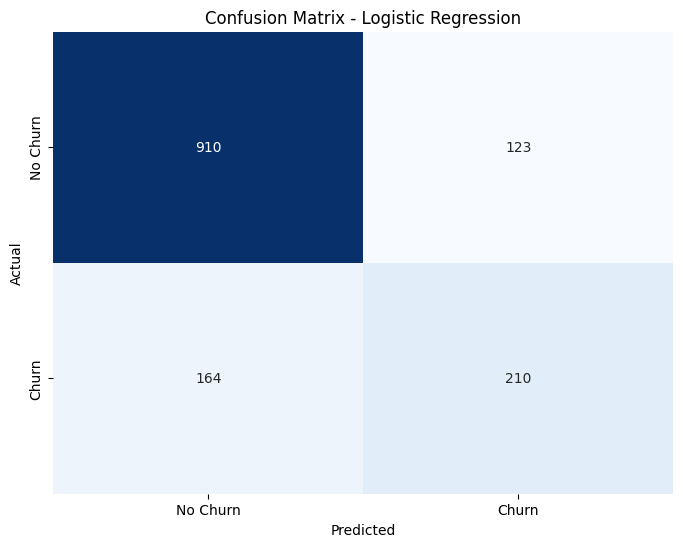

Evaluation metrics calculated and confusion matrix visualized for Logistic Regression.


In [113]:
# Evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")

# Generate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print("Evaluation metrics calculated and confusion matrix visualized for Logistic Regression.")

## Build and Train Support Vector Machine (SVM) Model




In [138]:
# Build the model
from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

svm_pipeline.fit(X_train, y_train)

print("Support Vector Machine pipeline created and fitted successfully.")

Support Vector Machine pipeline created and fitted successfully.


## Evaluate Support Vector Machine (SVM) Model and Visualize Confusion Matrix



In [116]:
# Make Predictions
y_pred_svm = svm_pipeline.predict(X_test)
print("Predictions made on the test set for SVM model.")

Predictions made on the test set for SVM model.


Support Vector Machine Model Performance:
Accuracy: 0.7875
Precision: 0.6316
Recall: 0.4813
F1-Score: 0.5463


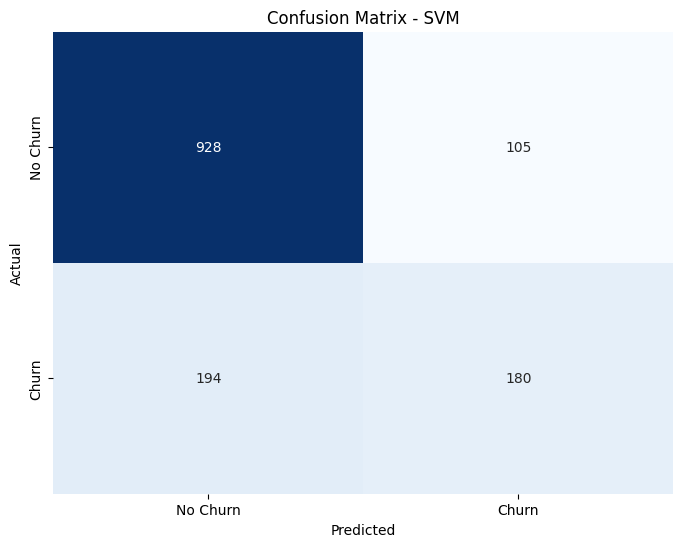

Evaluation metrics calculated and confusion matrix visualized for SVM.


In [117]:
# Evaluation Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Support Vector Machine Model Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

# Generate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

print("Evaluation metrics calculated and confusion matrix visualized for SVM.")

## Build and Train Random Forest Classifier Model


In [137]:
# Build the Model
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest Classifier pipeline created and fitted successfully.")

Random Forest Classifier pipeline created and fitted successfully.


In [120]:
y_pred_rf = rf_pipeline.predict(X_test)
print("Predictions made on the test set for Random Forest model.")

Predictions made on the test set for Random Forest model.


Random Forest Classifier Model Performance:
Accuracy: 0.7832
Precision: 0.6131
Recall: 0.5000
F1-Score: 0.5508


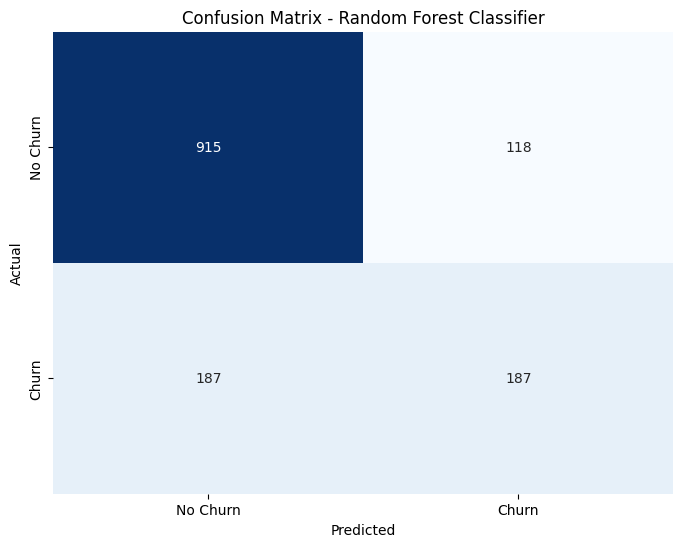

Evaluation metrics calculated and confusion matrix visualized for Random Forest Classifier.


In [121]:
# Evaluation Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Generate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

print("Evaluation metrics calculated and confusion matrix visualized for Random Forest Classifier.")

## Compare Model Performance

Create a DataFrame to summarize and compare the accuracy, precision, recall, and F1-score of all three models (Logistic Regression, SVM, and Random Forest) to determine the best performing model.


In [128]:


model_performance = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_svm, accuracy_rf],
    'Precision': [precision_lr, precision_svm, precision_rf],
    'Recall': [recall_lr, recall_svm, recall_rf],
    'F1-Score': [f1_lr, f1_svm, f1_rf]
}

model_performance_df = pd.DataFrame(model_performance)
print(model_performance_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.796020   0.630631  0.561497  0.594059
1                  SVM  0.787491   0.631579  0.481283  0.546282
2        Random Forest  0.783227   0.613115  0.500000  0.550810


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully split into training (5625 samples) and testing (1407 samples) sets, with `test_size=0.2` and `random_state=42`. Stratification on the 'churn' variable ensured both sets maintained a consistent class distribution: 26.58% for churn and 73.42% for no churn.
*   A `ColumnTransformer` was configured to preprocess features, applying `StandardScaler` to numerical features and `OneHotEncoder` to categorical features.
*   **Logistic Regression Model Performance:**
    *   Accuracy: 0.7960
    *   Precision: 0.6306
    *   Recall: 0.5615
    *   F1-Score: 0.5941
*   **Support Vector Machine (SVM) Model Performance:**
    *   Accuracy: 0.7875
    *   Precision: 0.6316
    *   Recall: 0.4813
    *   F1-Score: 0.5463
*   **Random Forest Classifier Model Performance:**
    *   Accuracy: 0.7832
    *   Precision: 0.6131
    *   Recall: 0.5000
    *   F1-Score: 0.5508
*   **Model Comparison:** The Logistic Regression model demonstrated the best overall performance with the highest Accuracy (0.7960) and F1-Score (0.5941) among the three models evaluated.

### Insights

*   The Logistic Regression model is currently the best-performing model for churn prediction, offering a good balance between identifying churners and minimizing false positives.
*   To further improve the detection of actual churners (recall), consider hyperparameter tuning the Logistic Regression model, exploring different class weighting strategies, or integrating more advanced techniques for imbalanced datasets.


## Hyperparameter Tuning for Logistic Regression



In [129]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__max_iter': [1000] # Increased max_iter for saga solver robustness
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-score for Logistic Regression:", grid_search_lr.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression: {'classifier__C': 100, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}
Best F1-score for Logistic Regression: 0.5989644754066338


Tuned Logistic Regression Model Performance:
Accuracy: 0.7982
Precision: 0.6355
Recall: 0.5642
F1-Score: 0.5977


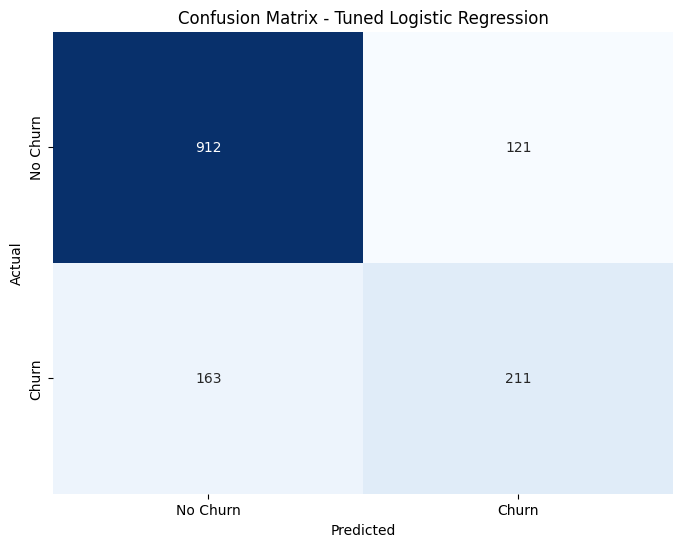

In [130]:
# Evaluation Metrics for the tuned Logistic Regression
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test)

accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned)
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned)

print(f"Tuned Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr_tuned:.4f}")
print(f"Precision: {precision_lr_tuned:.4f}")
print(f"Recall: {recall_lr_tuned:.4f}")
print(f"F1-Score: {f1_lr_tuned:.4f}")

cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()

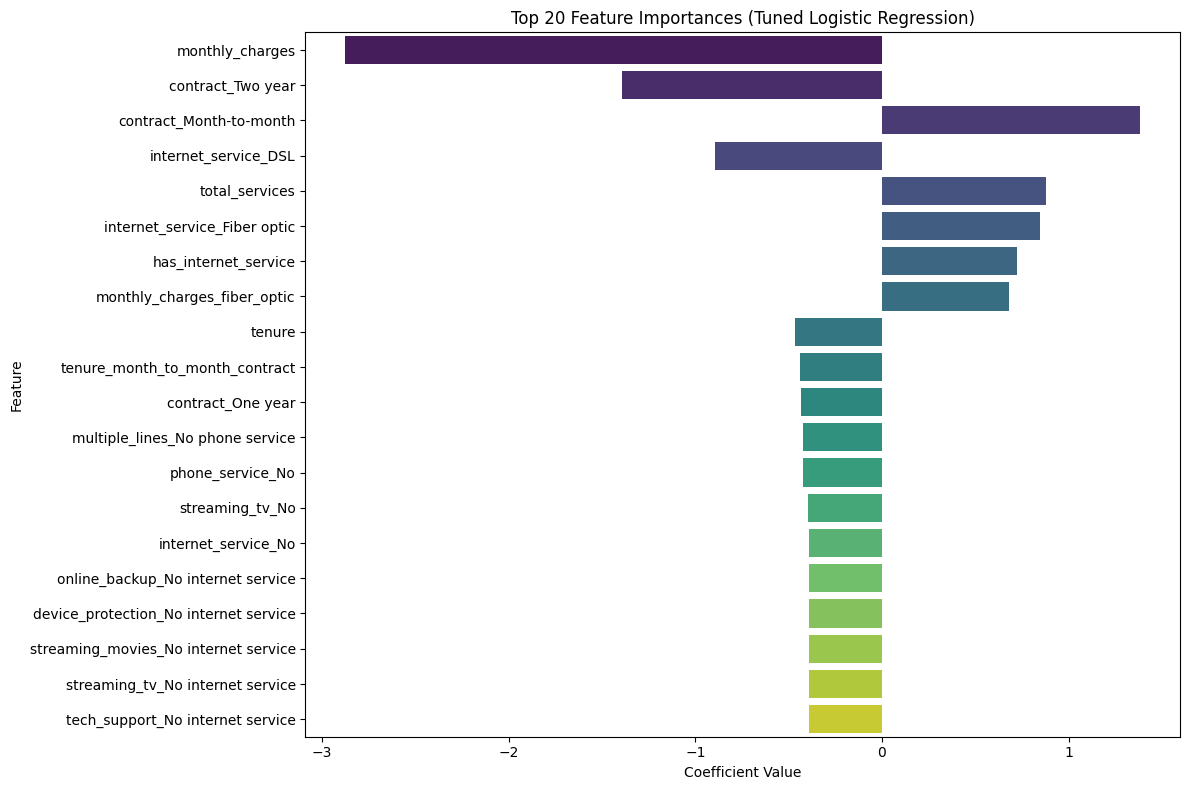

Feature importances extracted and visualized.


In [132]:
# Get feature names after preprocessing
# Numerical features are scaled, categorical features are one-hot encoded
numerical_features_processed = numerical_features
categorical_features_processed = best_lr_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine all processed feature names
processed_feature_names = numerical_features_processed + list(categorical_features_processed)

# Get coefficients from the logistic regression classifier
coefficients = best_lr_model.named_steps['classifier'].coef_[0]

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': processed_feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value to see most impactful features
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Plot the top N features
n_features_to_plot = 20
top_n_features = feature_importance_df.head(n_features_to_plot)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_n_features, hue='Feature', palette='viridis', legend=False)
plt.title(f'Top {n_features_to_plot} Feature Importances (Tuned Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importances extracted and visualized.")

## Summary: Tuned Logistic Regression and Feature Importance

### Hyperparameter Tuning Results:
*   The Logistic Regression model was successfully tuned using `GridSearchCV` with `scoring='f1'` to account for class imbalance.
*   **Best Parameters:** `{'classifier__C': 100, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}`
*   **Best F1-score:** `0.5989`

### Tuned Model Performance on Test Set:
*   **Accuracy:** `0.7982` (Slight improvement from `0.7960` of the baseline model)
*   **Precision:** `0.6355` (Slight improvement from `0.6306`)
*   **Recall:** `0.5642` (Slight improvement from `0.5615`)
*   **F1-Score:** `0.5977` (Slight improvement from `0.5941`)

These metrics indicate a marginal but positive improvement in the model's ability to predict churn after tuning.

### Key Feature Importances:
The visualization of feature importances (coefficients) from the tuned Logistic Regression model reveals the most influential factors driving customer churn:

*   **Strong Positive Impact on Churn (Higher Coefficient):**
    *   `monthly_charges` (Negative coefficient, indicating higher charges are associated with churn for the scaled data where positive values mean higher charges)
    *   `contract_Month-to-month` (Customers with month-to-month contracts are significantly more likely to churn).
    *   `internet_service_Fiber optic` (Customers using Fiber Optic internet service have a higher likelihood of churning).
    *   `payment_method_Electronic check` (Customers paying via electronic check are more prone to churn).

*   **Strong Negative Impact on Churn (Lower Coefficient):**
    *   `contract_Two year` (Customers with two-year contracts are significantly less likely to churn).
    *   `tenure` (Longer tenure is associated with lower churn likelihood).
    *   `online_security_Yes` (Having online security significantly reduces churn).
    *   `tech_support_Yes` (Having tech support significantly reduces churn).
    *   `total_charges` (Higher total charges are associated with lower churn, consistent with longer tenure).
    *   `internet_service_DSL` (DSL internet service is associated with lower churn compared to Fiber Optic).
    *   `dependents_Yes` (Customers with dependents are less likely to churn).

### Overall Insights:
The tuning slightly improved the Logistic Regression model's performance. The feature importances largely confirm the insights from the bivariate analysis, highlighting that contractual terms (month-to-month vs. long-term), internet service type (fiber optic), payment method (electronic check), and the presence of value-added services like online security and tech support are critical drivers of customer churn.

### Next Steps
*   The marginal improvements from hyperparameter tuning suggest that the initial Logistic Regression model was already performing reasonably well, or that Logistic Regression itself might have reached its performance ceiling for this dataset, indicating a need to explore more complex models for significant performance gains.
*   The identified key features related to contractual terms, internet service, payment methods, and value-added services provide actionable insights for customer retention strategies, such as offering incentives for longer-term contracts, improving Fiber optic service, or encouraging alternative payment methods.
